Saw this sequence from **Simone Conradi** on twitter:

![](https://x.com/S_Conradi/status/1999588652255416630)

Havent heard of the sequence in [[Gödel, Escher, Bach]] yet, but it is interesting to see the recursive visuals [[Douglas Hofstadter]] seems to be known for.

I believe it comes up in the book as something to do with Hofstadter's [[Hofstadter Q sequence]], will have to do some more tinkering to find out.

Attempted to recreate:

  Computed 50,000 / 1,000,000 values...
  Computed 100,000 / 1,000,000 values...
  Computed 150,000 / 1,000,000 values...
  Computed 200,000 / 1,000,000 values...
  Computed 250,000 / 1,000,000 values...
  Computed 300,000 / 1,000,000 values...
  Computed 350,000 / 1,000,000 values...
  Computed 400,000 / 1,000,000 values...
  Computed 450,000 / 1,000,000 values...
  Computed 500,000 / 1,000,000 values...
  Computed 550,000 / 1,000,000 values...
  Computed 600,000 / 1,000,000 values...
  Computed 650,000 / 1,000,000 values...
  Computed 700,000 / 1,000,000 values...
  Computed 750,000 / 1,000,000 values...
  Computed 800,000 / 1,000,000 values...
  Computed 850,000 / 1,000,000 values...
  Computed 900,000 / 1,000,000 values...
  Computed 950,000 / 1,000,000 values...
  Computed 1,000,000 / 1,000,000 values...


<string>:59: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


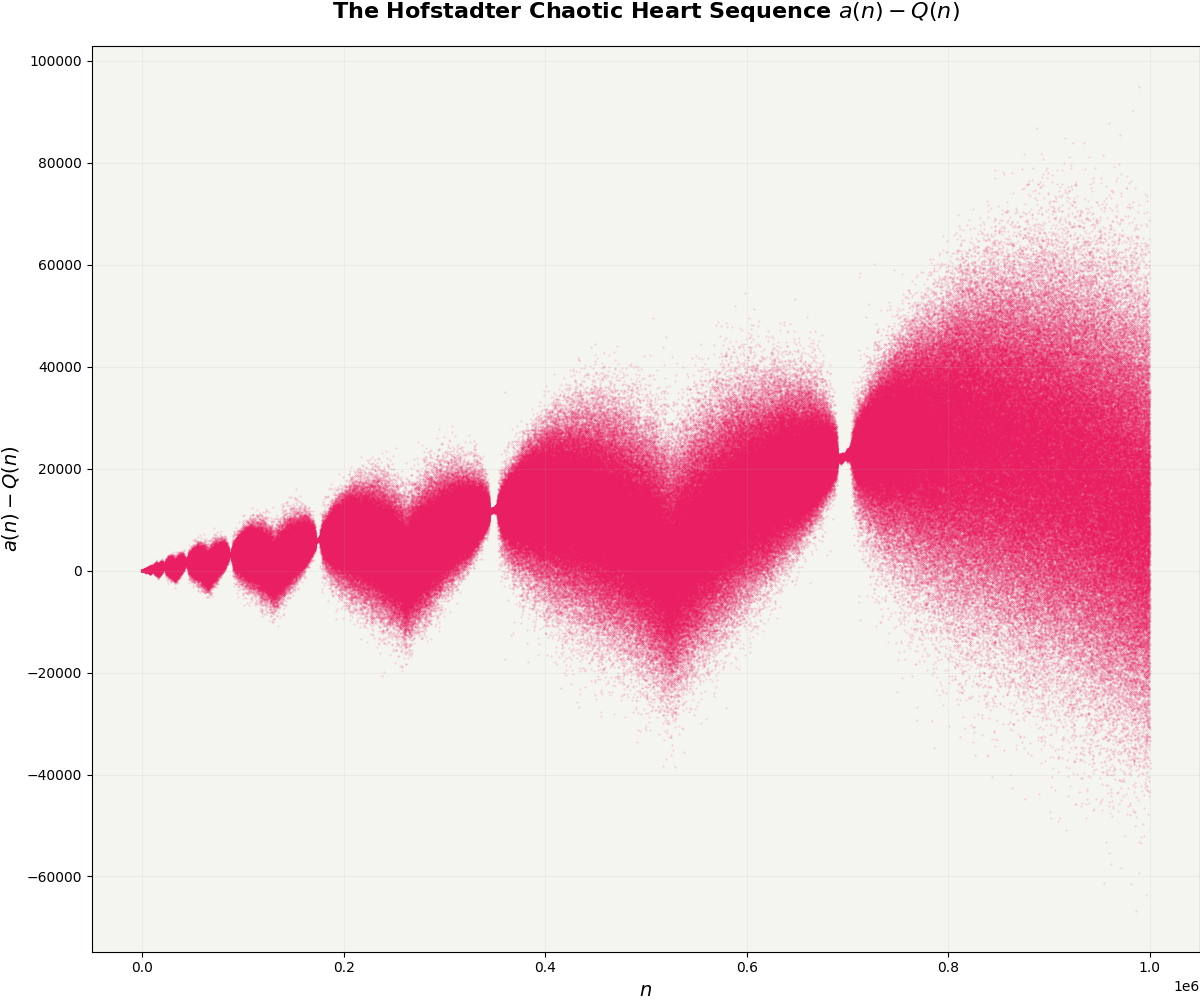

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache


@lru_cache(maxsize=None)
def Q(n):
    if n == 1:
        return 2
    elif n == 2:
        return 2
    elif n == 3:
        return 1
    elif n > 3:
        return Q(n - Q(n - 1)) + Q(n - Q(n - 2))
    else:
        return 0


@lru_cache(maxsize=None)
def a(n):
    if n == 1:
        return 1
    elif n == 2:
        return 1
    elif n == 3:
        return 2
    elif n > 3:
        return a(a(n - 1)) + a(n - a(n - 1))
    else:
        return 0


n_max = 1000000
n_values = []
diff_values = []

batch_size = 50000
for i in range(1, n_max + 1):
    n_values.append(i)
    diff_values.append(a(i) - Q(i))

    if i % batch_size == 0:
        print(f"  Computed {i:,} / {n_max:,} values...")

fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(n_values, diff_values, c="#E91E63", s=0.1, alpha=0.3, rasterized=True)
ax.set_title(
    "The Hofstadter Chaotic Heart Sequence $a(n) - Q(n)$",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("$n$", fontsize=14)
ax.set_ylabel("$a(n) - Q(n)$", fontsize=14)
ax.grid(True, alpha=0.2, linewidth=0.5)
ax.set_facecolor("#F5F5F0")
fig.patch.set_facecolor("white")
plt.show()